# Objective

This project aims to analyze BBC news articles and automatically discover hidden topics using unsupervised machine learning. It applies Latent Semantic Analysis (LSA), Latent Dirichlet Allocation (LDA), and Non-negative Matrix Factorization (NMF) for topic modelling.
The text data is cleaned and converted into numerical form using vectorization techniques.
Each model is used to identify patterns and group similar documents together.
The goal is to compare how effectively these methods extract meaningful topics.
This helps in understanding large collections of unstructured text automatically

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation, NMF

import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yufengdev/bbc-fulltext-and-category")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bbc-fulltext-and-category' dataset.
Path to dataset files: /kaggle/input/bbc-fulltext-and-category


In [4]:
import os

# The file identified by os.listdir(path) is 'bbc-text.csv'.
csv_file_name = 'bbc-text.csv'

# Construct the full path to the CSV file.
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


# Check Datatype

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   category    2225 non-null   object
 1   text        2225 non-null   object
 2   clean_text  2225 non-null   object
 3   LSA_Topic   2225 non-null   int64 
 4   LDA_Topic   2225 non-null   int64 
 5   NMF_Topic   2225 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 104.4+ KB


# 5 Points Summary Data

In [19]:
df.describe()

,LSA_Topic,LDA_Topic,NMF_Topic
count,2225.000000,2225.000000,2225.000000
mean,0.439551,2.163146,2.117753
std,1.062380,1.349757,1.408024
min,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000
50%,0.000000,2.000000,2.000000
75%,0.000000,3.000000,3.000000
max,4.000000,4.000000,4.000000


# Check Null Values

In [21]:
df.isnull().sum()

,0
category,0
text,0
clean_text,0
LSA_Topic,0
LDA_Topic,0
NMF_Topic,0


# Text Cleaning

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

# TF-IDF Vectorizer

In [6]:
# TF-IDF for LSA & NMF
tfidf = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_dtm = tfidf.fit_transform(df["clean_text"])

# Count for LDA
cv = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
cv_dtm = cv.fit_transform(df["clean_text"])


# LSA (Truncated SVD)

In [7]:
num_topics = 5

lsa_model = TruncatedSVD(n_components=num_topics, random_state=42)
lsa_model.fit(tfidf_dtm)

TruncatedSVD(n_components=5, random_state=42)

# LDA

In [8]:
lda_model = LatentDirichletAllocation(n_components=num_topics,
                                      random_state=42)
lda_model.fit(cv_dtm)


LatentDirichletAllocation(n_components=5, random_state=42)

# NMF

In [9]:
nmf_model = NMF(n_components=num_topics,
                random_state=42,
                init='nndsvda',
                max_iter=200)
nmf_model.fit(tfidf_dtm)


NMF(init='nndsvda', n_components=5, random_state=42)

# Display top words

In [10]:
def display_topics(model, feature_names, no_top_words=10, title="MODEL"):
    print(f"\n===== {title} TOPICS =====")
    for i, topic in enumerate(model.components_):
        print(f"\nTOPIC {i}")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

In [11]:
# # Feature names
tfidf_features = tfidf.get_feature_names_out()
cv_features = cv.get_feature_names_out()

In [12]:
# Show topics
display_topics(lsa_model, tfidf_features, title="LSA")
display_topics(lda_model, cv_features, title="LDA")
display_topics(nmf_model, tfidf_features, title="NMF")


===== LSA TOPICS =====

TOPIC 0
said mr year people labour election government game new blair

TOPIC 1
mr labour election blair party brown tory tax minister howard

TOPIC 2
film award best win game england labour blair oscar wale

TOPIC 3
film award best oscar actor festival actress nomination director music

TOPIC 4
mobile phone people technology user music game digital service microsoft

===== LDA TOPICS =====

TOPIC 0
said people game technology mobile phone service music new user

TOPIC 1
film year said best award new music star world british

TOPIC 2
said year company firm mr market bank new sale growth

TOPIC 3
said mr government labour party people minister election say blair

TOPIC 4
said game player england win time club year play match

===== NMF TOPICS =====

TOPIC 0
mobile phone people technology music service digital user said broadband

TOPIC 1
mr labour election blair party brown tory said tax minister

TOPIC 2
game england player win wale match team said ireland cup



# Assign topics to documents

In [13]:
df["LSA_Topic"] = lsa_model.transform(tfidf_dtm).argmax(axis=1)
df["LDA_Topic"] = lda_model.transform(cv_dtm).argmax(axis=1)
df["NMF_Topic"] = nmf_model.transform(tfidf_dtm).argmax(axis=1)

print(df[["category", "LSA_Topic", "LDA_Topic", "NMF_Topic"]].head())

        category  LSA_Topic  LDA_Topic  NMF_Topic
0           tech          0          0          0
1       business          0          3          1
2          sport          0          4          2
3          sport          2          4          2
4  entertainment          0          1          3


# Visual Comparision

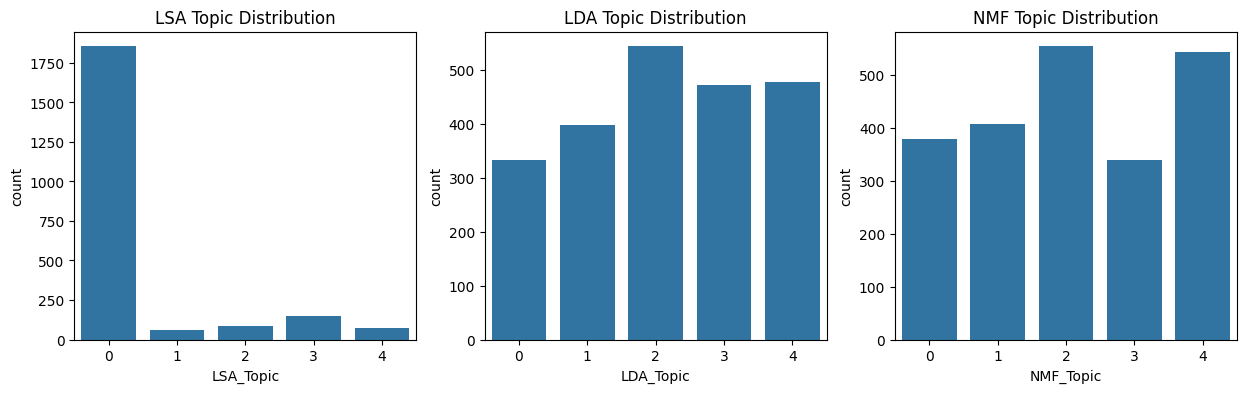

In [14]:

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.countplot(x="LSA_Topic", data=df)
plt.title("LSA Topic Distribution")

plt.subplot(1,3,2)
sns.countplot(x="LDA_Topic", data=df)
plt.title("LDA Topic Distribution")

plt.subplot(1,3,3)
sns.countplot(x="NMF_Topic", data=df)
plt.title("NMF Topic Distribution")

plt.show()

# Conclusion

The project successfully extracted meaningful topics from BBC news articles using LSA, LDA, and NMF.
All three models were able to group documents into major news categories.
NMF produced the most clear and interpretable topics, while LDA showed probabilistic topic distribution.
LSA captured semantic relationships but was less interpreable compared to the others.
Overall, topic modelling proved effective for organizing large text datasets.
This approach can be useful in applications like news analysis, search engines, and recommendation systems